# Visualizing the Christoffel-Darboux Polynomial

The **Christoffel-Darboux (CD) polynomial** measures how "surprising" a point $x$ is relative to a training distribution. Given data $\{x_i\}_{i=1}^n$ and a polynomial basis $\{v_j\}_{j=1}^p$:

$$P_D(x) = \| L^{-T} v(x) \|^2$$

where $v(x)$ is the vector of basis evaluations at $x$, and $L$ is the Cholesky factor of the empirical moment matrix $M = V^\top V / n$.

**Key property (Lemma 3):** $\mathbb{E}[P_D(x)] \approx p$ (number of basis terms) — meaning the polynomial is approximately flat on the support and blows up outside it.

This notebook visualizes how the CD polynomial behaves across different distributions, polynomial bases, and compares it to the **kernelized** variant.

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import solve_triangular
from sklearn.datasets import make_moons

from algs.bases.poly_basis import BasisSpec, MonomialBasis, ChebyshevBasis
from algs.kern_cd import KernCD
from algs.kernels import RBF

np.random.seed(42)
plt.style.use("seaborn-v0_8")
plt.rcParams.update({"figure.dpi": 120})

In [7]:
class CDPoly:
    """Minimal numpy CD polynomial using the torch-based poly_basis for features."""

    def __init__(self, data, degree, basis="cheb", eps=1e-10):
        n, d = data.shape
        spec = BasisSpec(n_vars=d, degree=degree)
        if basis == "mon":
            self.basis = MonomialBasis(spec)
        else:
            self.basis = ChebyshevBasis(spec)

        V = self.basis.transform(torch.as_tensor(data, dtype=torch.float64)).numpy()
        self.n_terms = V.shape[1]

        # Moment matrix + Cholesky
        V_bar = V / np.sqrt(n)
        M = V_bar.T @ V_bar + eps * np.eye(self.n_terms)
        self.L = np.linalg.cholesky(M)

    def __call__(self, x):
        v = self.basis.transform(torch.as_tensor(x, dtype=torch.float64)).numpy()
        y = solve_triangular(self.L, v.T, lower=True).T
        return np.einsum("bi,bi->b", y, y)


def eval_grid(func, xx, yy):
    """Evaluate a callable on a meshgrid."""
    pts = np.column_stack([xx.ravel(), yy.ravel()])
    return func(pts).reshape(xx.shape)

## 1. 1D CD Polynomial — Varying Distributions

We fit a degree-6 Chebyshev CD polynomial to four different 1D distributions and plot $P_D(x)$ vs $x$. The polynomial should be relatively flat on the data support and rise steeply outside.

Text(0.5, 0.98, '1D CD Polynomial (Chebyshev, degree=6) — Different Distributions')

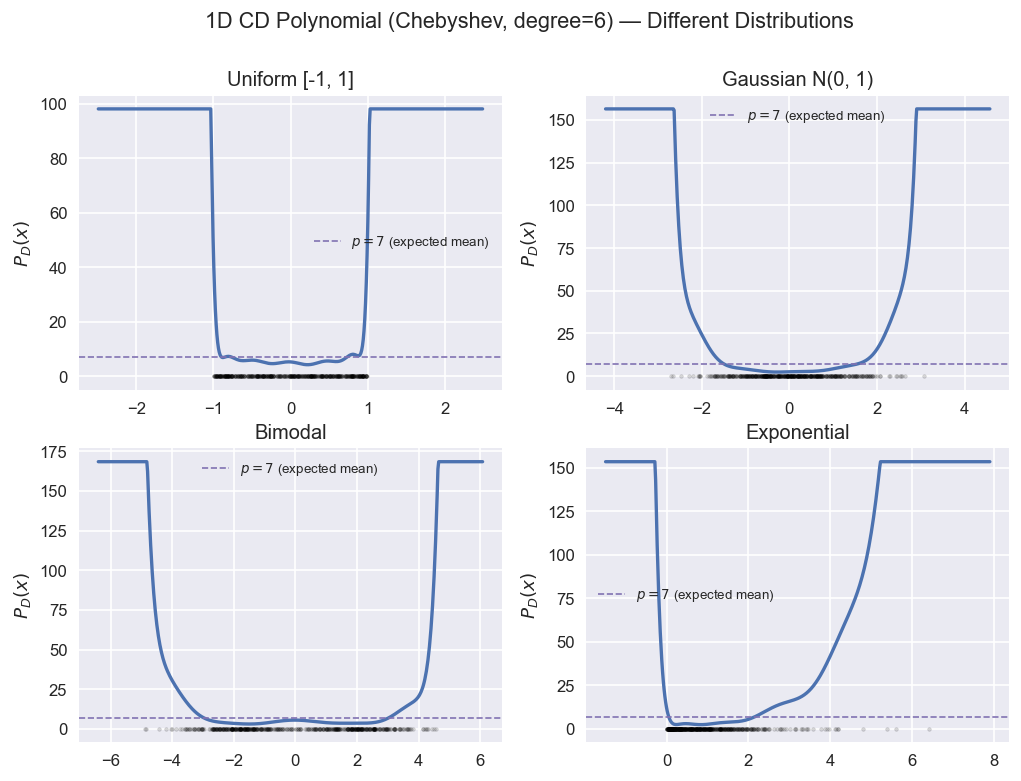

In [8]:
n = 500
degree = 6

distributions = {
    "Uniform [-1, 1]": np.random.uniform(-1, 1, n),
    "Gaussian N(0, 1)": np.random.randn(n),
    "Bimodal": np.concatenate([np.random.randn(n // 2) - 2, np.random.randn(n // 2) + 2]),
    "Exponential": np.random.exponential(1, n),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, (name, data) in zip(axes.flat, distributions.items()):
    data_2d = data[:, None]  # (n, 1)
    cd = CDPoly(data_2d, degree=degree, basis="cheb")

    # Evaluation grid
    lo, hi = data.min() - 1.5, data.max() + 1.5
    t = np.linspace(lo, hi, 500)[:, None]
    vals = cd(t)

    # Clip for visualization (CD blows up outside support)
    clip = np.percentile(cd(data_2d), 99) * 3
    vals_clipped = np.clip(vals, 0, clip)

    ax.plot(t, vals_clipped, color="C0", lw=2)
    ax.scatter(data, np.zeros_like(data), color="k", alpha=0.15, s=5, zorder=3)
    ax.axhline(cd.n_terms, color="C3", ls="--", lw=1, label=f"$p = {cd.n_terms}$ (expected mean)")
    ax.set_title(name)
    ax.set_ylabel("$P_D(x)$")
    ax.legend(fontsize=8)

fig.suptitle(f"1D CD Polynomial (Chebyshev, degree={degree}) — Different Distributions", fontsize=13)

## 2. 1D CD Polynomial — Basis and Degree Comparison

Fix the Gaussian distribution and compare **Monomial** vs **Chebyshev** bases at degrees 3, 6, and 10.

Text(0.5, 0.98, 'Monomial vs Chebyshev Basis — Gaussian Data')

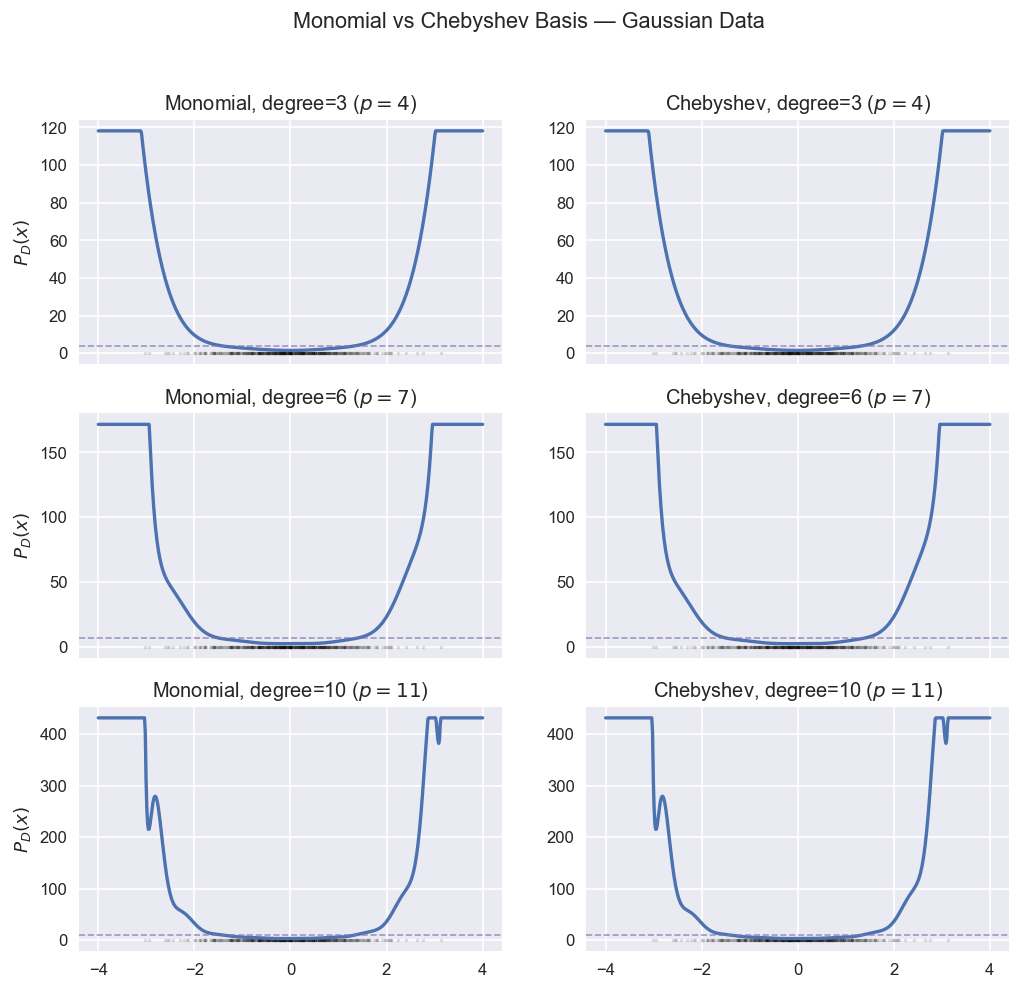

In [9]:
data_1d = np.random.randn(500)[:, None]
degrees = [3, 6, 10]
bases = ["mon", "cheb"]

fig, axes = plt.subplots(len(degrees), len(bases), figsize=(10, 9), sharex=True)

t = np.linspace(-4, 4, 500)[:, None]

for i, deg in enumerate(degrees):
    for j, basis in enumerate(bases):
        ax = axes[i, j]
        cd = CDPoly(data_1d, degree=deg, basis=basis)
        vals = cd(t)

        clip = np.percentile(cd(data_1d), 99) * 3
        vals_clipped = np.clip(vals, 0, clip)

        ax.plot(t, vals_clipped, color="C0", lw=2)
        ax.scatter(data_1d, np.zeros_like(data_1d), color="k", alpha=0.1, s=3)
        ax.axhline(cd.n_terms, color="C3", ls="--", lw=1, alpha=0.7)
        ax.set_title(f"{'Monomial' if basis == 'mon' else 'Chebyshev'}, degree={deg} ($p={cd.n_terms}$)")
        if j == 0:
            ax.set_ylabel("$P_D(x)$")

fig.suptitle("Monomial vs Chebyshev Basis — Gaussian Data", fontsize=13)

## 3. 2D Contour Plots — Different Distributions

Surface (3D) and contour (2D) plots of the CD polynomial for four 2D distributions.

In [10]:
# Generate 2D datasets
n2d = 1000

# Gaussian blob
gauss_2d = np.random.randn(n2d, 2) * 0.8

# Ring
theta = np.random.uniform(0, 2 * np.pi, n2d)
ring_2d = np.column_stack([np.cos(theta), np.sin(theta)]) + 0.15 * np.random.randn(n2d, 2)

# Two moons
moons_2d, _ = make_moons(n2d, noise=0.08)

# Mixture of 3 Gaussians
centers = np.array([[0, 2], [-1.5, -1], [1.5, -1.0]])
mix_idx = np.random.choice(3, n2d)
mix_2d = centers[mix_idx] + 0.35 * np.random.randn(n2d, 2)

datasets_2d = {
    "Gaussian Blob": gauss_2d,
    "Ring": ring_2d,
    "Two Moons": moons_2d,
    "3-Gaussian Mixture": mix_2d,
}

Text(0.5, 1.01, '2D CD Polynomial (Chebyshev, degree=6)')

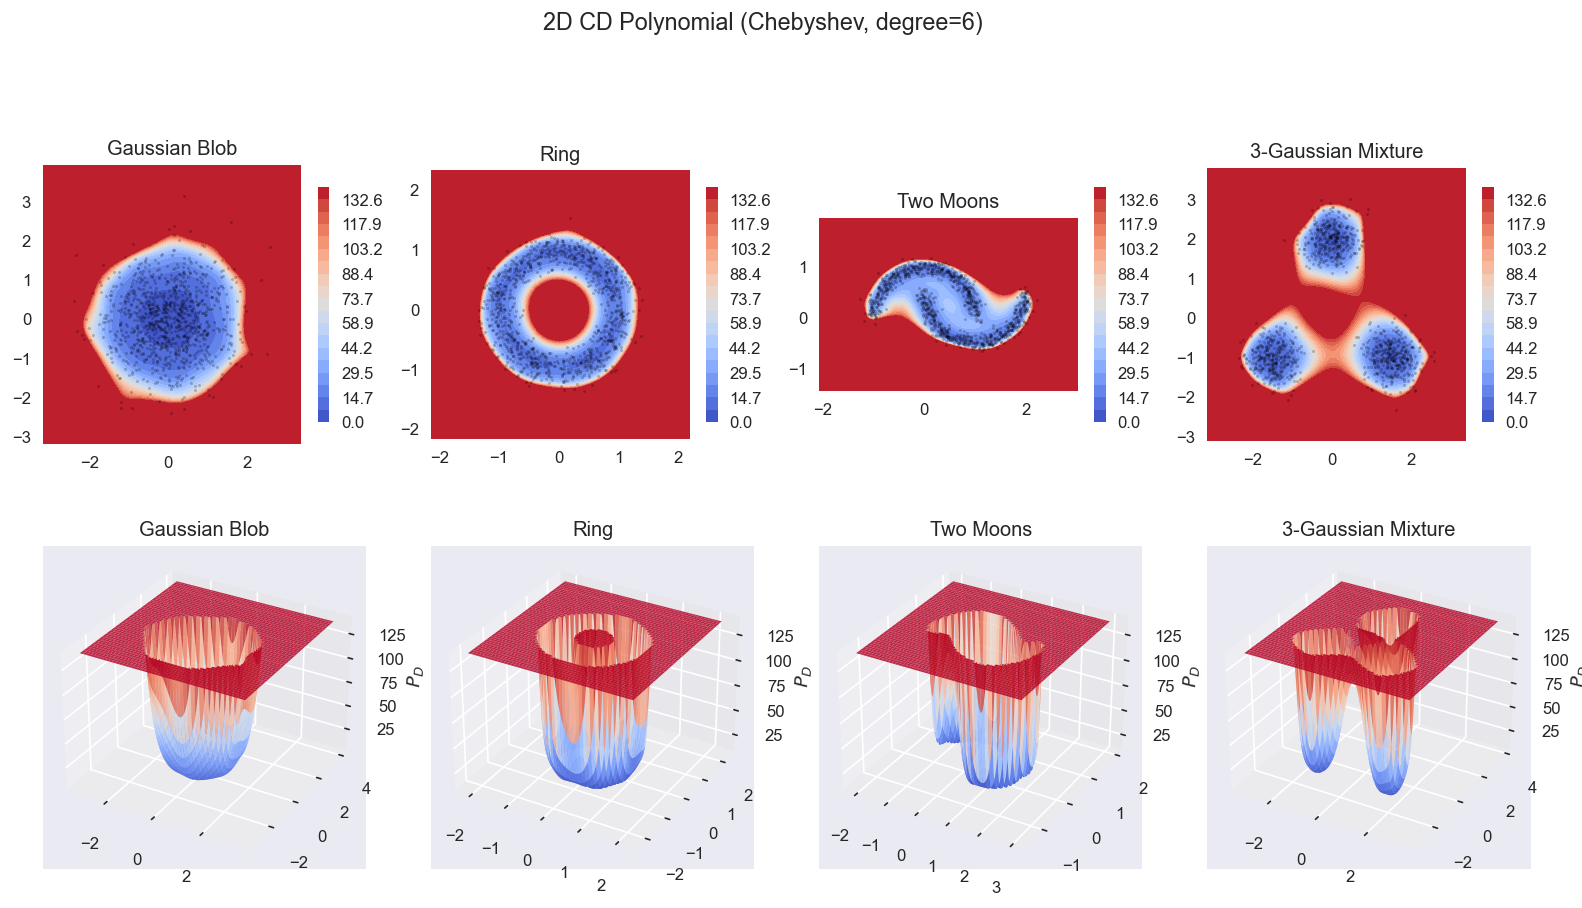

In [11]:
# 2D contour plots
degree_2d = 6

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (name, data) in enumerate(datasets_2d.items()):
    cd = CDPoly(data, degree=degree_2d, basis="cheb")
    mean_val = cd(data).mean()

    # Grid
    margin = 0.8
    x_lo, x_hi = data[:, 0].min() - margin, data[:, 0].max() + margin
    y_lo, y_hi = data[:, 1].min() - margin, data[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_lo, x_hi, 200), np.linspace(y_lo, y_hi, 200))
    zz = eval_grid(cd, xx, yy)

    # Clip at a reasonable threshold for visualization
    clip_val = mean_val * 5
    zz_clip = np.clip(zz, 0, clip_val)

    # Contour plot (top row)
    ax = axes[0, col]
    levels = np.linspace(0, clip_val, 20)
    cf = ax.contourf(xx, yy, zz_clip, levels=levels, cmap="coolwarm")
    ax.scatter(*data.T, color="k", s=2, alpha=0.2)
    ax.set_title(name)
    ax.set_aspect("equal")
    plt.colorbar(cf, ax=ax, shrink=0.7)

    # 3D surface plot (bottom row)
    ax3 = fig.add_subplot(2, 4, 4 + col + 1, projection="3d")
    axes[1, col].set_visible(False)  # hide the 2D axis
    ax3.plot_surface(xx, yy, zz_clip, cmap="coolwarm", alpha=0.85, edgecolor="none")
    ax3.set_title(name)
    ax3.set_zlabel("$P_D$")

fig.suptitle(f"2D CD Polynomial (Chebyshev, degree={degree_2d})", fontsize=14, y=1.01)

## 4. 2D Basis and Degree Comparison

Fix the **ring** distribution and compare Monomial vs Chebyshev at degrees 3, 6, and 10.

Text(0.5, 0.98, 'Ring Data — Basis and Degree Comparison')

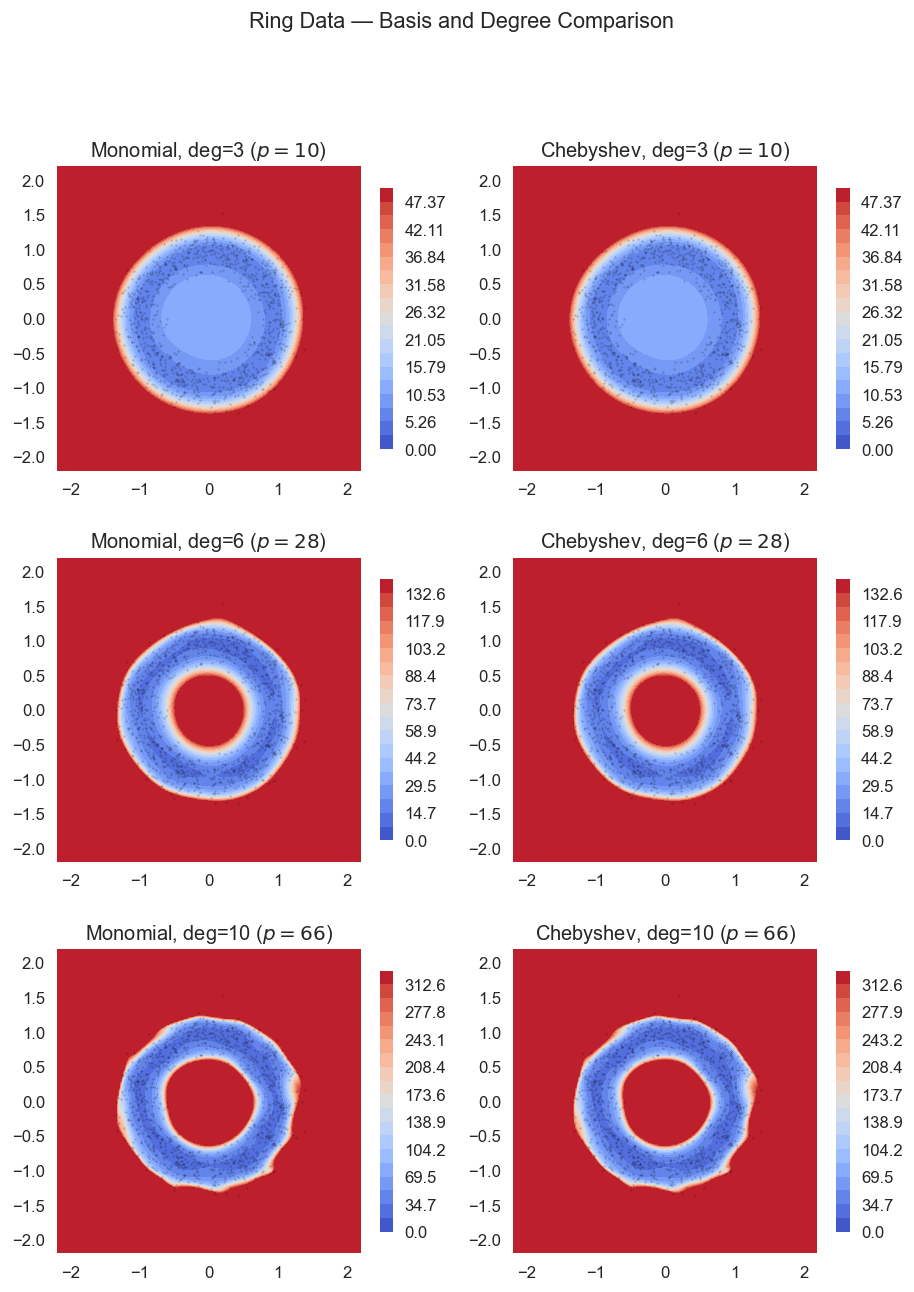

In [12]:
degrees_cmp = [3, 6, 10]
bases_cmp = [("mon", "Monomial"), ("cheb", "Chebyshev")]
data_ring = ring_2d

xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 200), np.linspace(-2.2, 2.2, 200))

fig, axes = plt.subplots(len(degrees_cmp), len(bases_cmp), figsize=(9, 12))

for i, deg in enumerate(degrees_cmp):
    for j, (basis_key, basis_label) in enumerate(bases_cmp):
        ax = axes[i, j]
        cd = CDPoly(data_ring, degree=deg, basis=basis_key)
        zz = eval_grid(cd, xx, yy)

        mean_val = cd(data_ring).mean()
        clip_val = mean_val * 5
        zz_clip = np.clip(zz, 0, clip_val)

        levels = np.linspace(0, clip_val, 20)
        cf = ax.contourf(xx, yy, zz_clip, levels=levels, cmap="coolwarm")
        ax.scatter(*data_ring.T, color="k", s=1, alpha=0.15)
        ax.set_title(f"{basis_label}, deg={deg} ($p={cd.n_terms}$)")
        ax.set_aspect("equal")
        plt.colorbar(cf, ax=ax, shrink=0.8)

fig.suptitle("Ring Data — Basis and Degree Comparison", fontsize=13)

## 5. Polynomial CD vs Kernelized CD (RBF Kernel)

Compare the classic polynomial CD to `KernCD` with an RBF (Gaussian) kernel on the same data.

**Key difference:** The polynomial CD uses explicit basis functions of a fixed degree. The kernelized CD implicitly uses an infinite-dimensional feature space defined by the kernel, controlled by the bandwidth $\gamma$ instead of degree.

### 5a. 1D Comparison

Text(0.5, 0.98, '1D: Polynomial CD vs Kernelized CD — Bimodal Data')

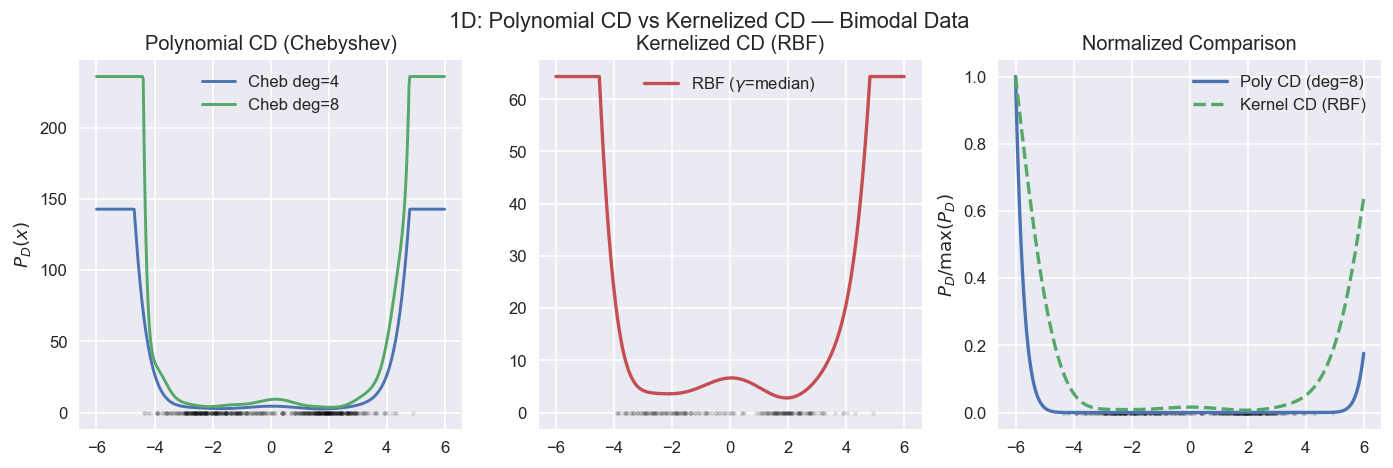

In [13]:
# 1D comparison: polynomial CD vs kernelized CD
data_bimodal = np.concatenate([np.random.randn(250) - 2, np.random.randn(250) + 2])[:, None]
n_sub = 200  # subsample for KernCD (kernel matrix is n x n)
data_kern = data_bimodal[np.random.choice(len(data_bimodal), n_sub, replace=False)]

t = np.linspace(-6, 6, 500)[:, None]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Polynomial CD
for deg in [4, 8]:
    cd = CDPoly(data_bimodal, degree=deg, basis="cheb")
    vals = cd(t)
    clip = np.percentile(cd(data_bimodal), 99) * 3
    axes[0].plot(t, np.clip(vals, 0, clip), label=f"Cheb deg={deg}")
axes[0].scatter(data_bimodal, np.zeros_like(data_bimodal), color="k", alpha=0.1, s=5)
axes[0].set_title("Polynomial CD (Chebyshev)")
axes[0].legend()
axes[0].set_ylabel("$P_D(x)$")

# Kernelized CD
kern_cd = KernCD(kernel=RBF(gamma="median"))
kern_cd.fit(data_kern)
vals_kern = kern_cd.predict(t)
clip_k = np.percentile(kern_cd.predict(data_kern), 99) * 3
axes[1].plot(t, np.clip(vals_kern, 0, clip_k), color="C2", lw=2, label=f"RBF ($\\gamma$=median)")
axes[1].scatter(data_kern, np.zeros_like(data_kern), color="k", alpha=0.1, s=5)
axes[1].set_title("Kernelized CD (RBF)")
axes[1].legend()

# Overlay comparison (normalized)
cd8 = CDPoly(data_bimodal, degree=8, basis="cheb")
vals_poly = cd8(t)
vals_poly_norm = vals_poly / vals_poly.max()
vals_kern_norm = vals_kern / vals_kern.max()

axes[2].plot(t, vals_poly_norm, label="Poly CD (deg=8)", lw=2)
axes[2].plot(t, vals_kern_norm, label="Kernel CD (RBF)", lw=2, ls="--")
axes[2].scatter(data_bimodal[:, 0], np.zeros(len(data_bimodal)), color="k", alpha=0.1, s=5)
axes[2].set_title("Normalized Comparison")
axes[2].set_ylabel("$P_D / \\max(P_D)$")
axes[2].legend()

fig.suptitle("1D: Polynomial CD vs Kernelized CD — Bimodal Data", fontsize=13)

### 5b. 2D Comparison — Ring and Two Moons

Text(0.5, 0.98, 'Polynomial CD vs Kernelized CD')

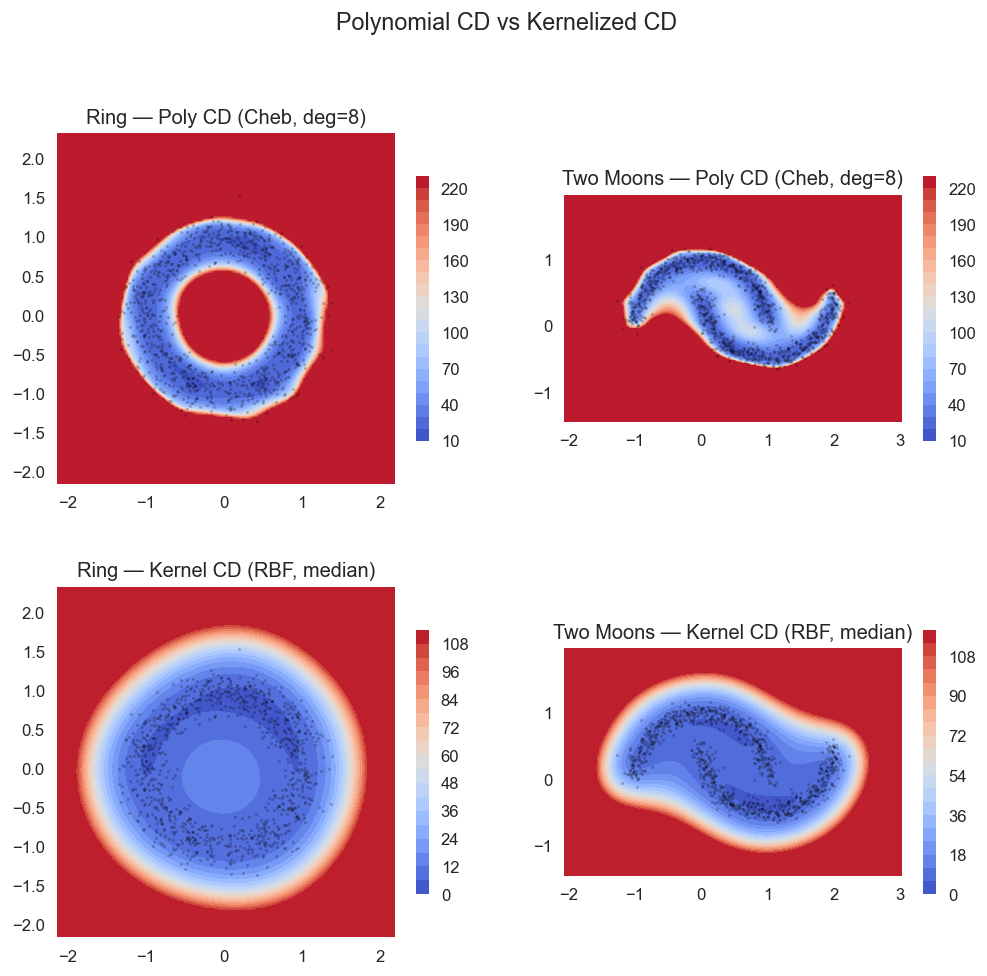

In [14]:
# 2D comparison: polynomial CD vs kernelized CD
compare_datasets = {"Ring": ring_2d, "Two Moons": moons_2d}

fig, axes = plt.subplots(2, len(compare_datasets), figsize=(10, 9))
n_sub = 300

for col, (name, data) in enumerate(compare_datasets.items()):
    margin = 0.8
    x_lo, x_hi = data[:, 0].min() - margin, data[:, 0].max() + margin
    y_lo, y_hi = data[:, 1].min() - margin, data[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_lo, x_hi, 150), np.linspace(y_lo, y_hi, 150))
    grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

    # Polynomial CD (top row)
    cd = CDPoly(data, degree=8, basis="cheb")
    zz_poly = eval_grid(cd, xx, yy)
    mean_poly = cd(data).mean()
    zz_poly_clip = np.clip(zz_poly, 0, mean_poly * 5)

    ax = axes[0, col]
    cf = ax.contourf(xx, yy, zz_poly_clip, levels=20, cmap="coolwarm")
    ax.scatter(*data.T, color="k", s=2, alpha=0.2)
    ax.set_title(f"{name} — Poly CD (Cheb, deg=8)")
    ax.set_aspect("equal")
    plt.colorbar(cf, ax=ax, shrink=0.7)

    # Kernelized CD (bottom row)
    idx = np.random.choice(len(data), n_sub, replace=False)
    kern_cd = KernCD(kernel=RBF(gamma="median"))
    kern_cd.fit(data[idx])
    zz_kern = kern_cd.predict(grid_pts).reshape(xx.shape)
    p99 = np.percentile(kern_cd.predict(data[idx]), 99)
    zz_kern_clip = np.clip(zz_kern, 0, p99 * 5)

    ax = axes[1, col]
    cf = ax.contourf(xx, yy, zz_kern_clip, levels=20, cmap="coolwarm")
    ax.scatter(*data.T, color="k", s=2, alpha=0.2)
    ax.set_title(f"{name} — Kernel CD (RBF, median)")
    ax.set_aspect("equal")
    plt.colorbar(cf, ax=ax, shrink=0.7)

fig.suptitle("Polynomial CD vs Kernelized CD", fontsize=14)

### 5c. 3D Surface — Polynomial vs Kernel on Two Moons

Text(0.5, 0.98, '3D Surface — Two Moons')

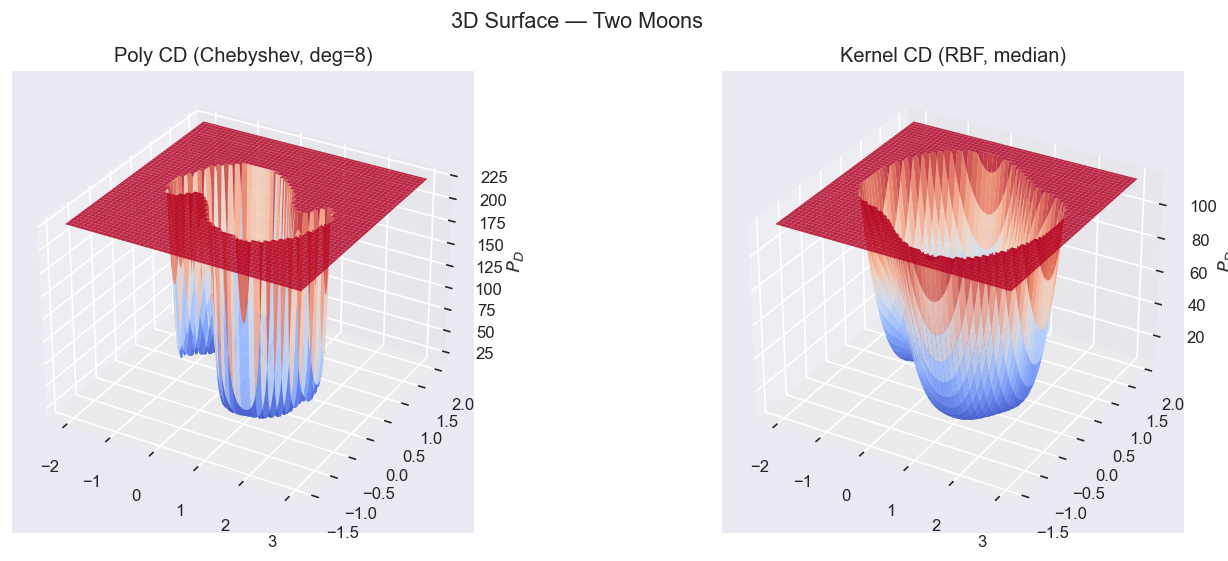

In [15]:
# 3D surface comparison on Two Moons
data = moons_2d
margin = 0.8
x_lo, x_hi = data[:, 0].min() - margin, data[:, 0].max() + margin
y_lo, y_hi = data[:, 1].min() - margin, data[:, 1].max() + margin
xx, yy = np.meshgrid(np.linspace(x_lo, x_hi, 150), np.linspace(y_lo, y_hi, 150))
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

# Polynomial
cd = CDPoly(data, degree=8, basis="cheb")
zz_poly = eval_grid(cd, xx, yy)
mean_poly = cd(data).mean()
zz_poly_clip = np.clip(zz_poly, 0, mean_poly * 5)

# Kernel
idx = np.random.choice(len(data), 300, replace=False)
kern_cd = KernCD(kernel=RBF(gamma="median"))
kern_cd.fit(data[idx])
zz_kern = kern_cd.predict(grid_pts).reshape(xx.shape)
p99 = np.percentile(kern_cd.predict(data[idx]), 99)
zz_kern_clip = np.clip(zz_kern, 0, p99 * 5)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(xx, yy, zz_poly_clip, cmap="coolwarm", alpha=0.85, edgecolor="none")
ax1.set_title("Poly CD (Chebyshev, deg=8)")
ax1.set_zlabel("$P_D$")
ax1.view_init(elev=30, azim=-60)

ax2 = fig.add_subplot(122, projection="3d")
ax2.plot_surface(xx, yy, zz_kern_clip, cmap="coolwarm", alpha=0.85, edgecolor="none")
ax2.set_title("Kernel CD (RBF, median)")
ax2.set_zlabel("$P_D$")
ax2.view_init(elev=30, azim=-60)

fig.suptitle("3D Surface — Two Moons", fontsize=13)

## 6. Kernel CD — Effect of RBF Bandwidth $\gamma$

The bandwidth $\gamma$ in the RBF kernel $k(x,y) = \exp(-\gamma \|x-y\|^2)$ plays a role analogous to polynomial degree:
- **Small $\gamma$** (wide kernel): smooth, oversmoothed level sets
- **Large $\gamma$** (narrow kernel): sharp, potentially overfitted level sets
- **Median heuristic**: a data-driven middle ground

In [17]:
# Compute median gamma for reference
from utils.misc import median_heuristic

data = ring_2d
n_sub = 300
idx = np.random.choice(len(data), n_sub, replace=False)
data_sub = data[idx]

gamma_med = median_heuristic(data_sub)
gammas = [gamma_med / 10, gamma_med, gamma_med * 10]
labels = [f"$\\gamma = {g:.2f}$ (0.1x median)", f"$\\gamma = {g:.2f}$ (median)", f"$\\gamma = {g:.2f}$ (10x median)"]

margin = 1.0
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 150), np.linspace(-2.5, 2.5, 150))
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, gamma, label in zip(axes, gammas, labels):
    kern_cd = KernCD(kernel=RBF(gamma=gamma))
    kern_cd.fit(data_sub)
    zz = kern_cd.predict(grid_pts).reshape(xx.shape)

    p99 = np.percentile(kern_cd.predict(data_sub), 99)
    zz_clip = np.clip(zz, 0, p99 * 5)

    cf = ax.contourf(xx, yy, zz_clip, levels=20, cmap="coolwarm")
    ax.scatter(*data.T, color="k", s=2, alpha=0.2)
    ax.set_title(label, fontsize=10)
    ax.set_aspect("equal")
    plt.colorbar(cf, ax=ax, shrink=0.7)

fig.suptitle("Ring Data — Kernel CD with Varying RBF Bandwidth", fontsize=13)

NameError: name 'g' is not defined

Text(0.5, 0.98, '3D Surface — Kernel CD Bandwidth Effect on Ring Data')

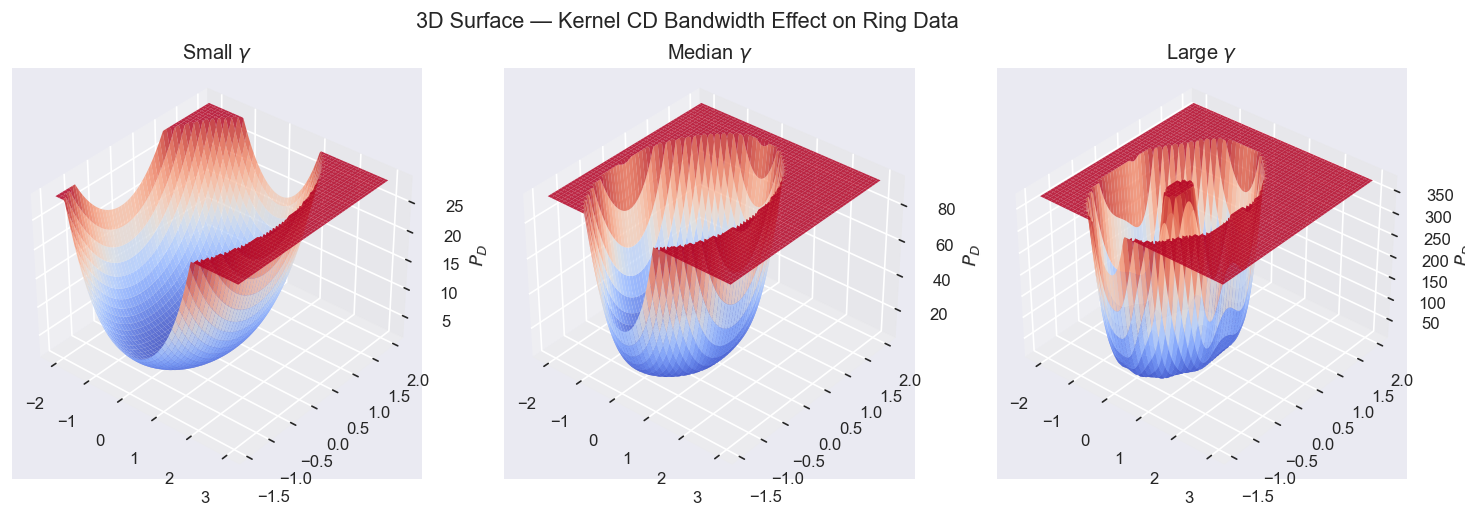

In [18]:
# 3D surface for the bandwidth comparison
fig = plt.figure(figsize=(15, 4.5))

for i, (gamma, label) in enumerate(zip(gammas, ["Small $\\gamma$", "Median $\\gamma$", "Large $\\gamma$"])):
    kern_cd = KernCD(kernel=RBF(gamma=gamma))
    kern_cd.fit(data_sub)
    zz = kern_cd.predict(grid_pts).reshape(xx.shape)
    p99 = np.percentile(kern_cd.predict(data_sub), 99)
    zz_clip = np.clip(zz, 0, p99 * 5)

    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.plot_surface(xx, yy, zz_clip, cmap="coolwarm", alpha=0.85, edgecolor="none")
    ax.set_title(label)
    ax.set_zlabel("$P_D$")
    ax.view_init(elev=35, azim=-50)

fig.suptitle("3D Surface — Kernel CD Bandwidth Effect on Ring Data", fontsize=13)